In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from faker import Faker
import random

In [2]:
# fake = Faker()
# num_users = 1000
# num_products = 50
# num_orders = 5000

# # 1. Users
# users_data = {
#     'user_id': [f'U{i}' for i in range(num_users)],
#     'name': [fake.name() for _ in range(num_users)],
#     'email': [fake.email() for _ in range(num_users)],
#     'gender': [random.choice(['Male', 'Female', 'Other']) for _ in range(num_users)],
#     'city': [fake.city() for _ in range(num_users)],
#     'signup_date': [fake.date_between(start_date='-2y', end_date='today') for _ in range(num_users)]
# }
# users_df = pd.DataFrame(users_data)

# # 2. Products
# categories = ['Electronics', 'Clothing', 'Beauty', 'Home', 'Sports']
# products_data = {
#     'product_id': [f'P{i}' for i in range(num_products)],
#     'product_name': [fake.catch_phrase() for _ in range(num_products)],
#     'category': [random.choice(categories) for _ in range(num_products)],
#     'price': [round(random.uniform(10, 500), 2) for _ in range(num_products)],
#     'rating': [round(random.uniform(3.5, 5.0), 1) for _ in range(num_products)]
# }
# products_df = pd.DataFrame(products_data)

# # 3. Orders
# orders_data = {
#     'order_id': [f'O{i}' for i in range(num_orders)],
#     'user_id': [random.choice(users_df['user_id']) for _ in range(num_orders)],
#     'order_date': [fake.date_time_between(start_date='-1y', end_date='now') for _ in range(num_orders)],
#     'order_status': [random.choices(['Completed', 'Cancelled', 'Returned'], weights=[0.85, 0.10, 0.05])[0] for _ in range(num_orders)],
# }
# orders_df = pd.DataFrame(orders_data)

# # 4. Order Items (Linking Orders to Products)
# items_list = []
# for order_id in orders_df['order_id']:
#     for _ in range(random.randint(1, 4)): # 1 to 4 products per order
#         p_id = random.choice(products_df['product_id'])
#         price = products_df.loc[products_df['product_id'] == p_id, 'price'].values[0]
#         items_list.append({
#             'order_item_id': fake.uuid4(),
#             'order_id': order_id,
#             'product_id': p_id,
#             'quantity': random.randint(1, 3),
#             'item_price': price
#         })
# order_items_df = pd.DataFrame(items_list)

# # Calculate total_amount for Orders table based on items
# totals = order_items_df.groupby('order_id').apply(lambda x: (x['quantity'] * x['item_price']).sum()).reset_index(name='total_amount')
# orders_df = orders_df.merge(totals, on='order_id', how='left')

# # 5. Reviews
# reviews_data = {
#     'review_id': [f'R{i}' for i in range(2000)],
#     'user_id': [random.choice(users_df['user_id']) for _ in range(2000)],
#     'product_id': [random.choice(products_df['product_id']) for _ in range(2000)],
#     'rating': [random.randint(1, 5) for _ in range(2000)],
#     'review_text': [fake.sentence() for _ in range(2000)],
#     'review_date': [fake.date_between(start_date='-1y', end_date='today') for _ in range(2000)]
# }
# reviews_df = pd.DataFrame(reviews_data)

# # 6. Events
# events_data = {
#     'event_id': [f'E{i}' for i in range(10000)],
#     'user_id': [random.choice(users_df['user_id']) for _ in range(10000)],
#     'product_id': [random.choice(products_df['product_id']) for _ in range(10000)],
#     'event_type': [random.choice(['view', 'cart', 'wishlist', 'purchase']) for _ in range(10000)],
#     'event_timestamp': [fake.date_time_between(start_date='-1y', end_date='now') for _ in range(10000)]
# }
# events_df = pd.DataFrame(events_data)

# # Save to CSV
# users_df.to_csv('users.csv', index=False)
# products_df.to_csv('products.csv', index=False)
# orders_df.to_csv('orders.csv', index=False)
# order_items_df.to_csv('order_items.csv', index=False)
# reviews_df.to_csv('reviews.csv', index=False)
# events_df.to_csv('events.csv', index=False)

# print("All 6 files generated successfully with correct relational links!")

In [ ]:
users = pd.read_csv(r"path\users.csv")
products = pd.read_csv(r"path\products.csv")
orders = pd.read_csv(r"path\orders.csv")
order_items = pd.read_csv(r"path\order_items.csv")
reviews = pd.read_csv(r"path\reviews.csv")
events = pd.read_csv(r"path\events.csv")

In [4]:
city_sales = orders.merge(users, on='user_id')
top_cities = city_sales.groupby('city')['total_amount'].sum().sort_values(ascending = False).head(5)
print("Cities By Revenues:")
print(top_cities)

Cities By Revenues:
city
South William       25475.94
Darrellhaven        24957.73
South Ashley        20862.80
South Jennifer      20080.31
Lake Gailborough    19570.90
Name: total_amount, dtype: float64


In [5]:
users['signup_date'] = pd.to_datetime(users['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
events['event_timestamp'] = pd.to_datetime(events['event_timestamp'])

## Using Funnel Logic

We need to count how many unique users performed each action in the events table. We focus on unique users because one person might "view" an item 10 times, but we only care that they are one person who entered the funnel.

In [6]:
funnel = events.groupby('event_type')['user_id'].nunique().reindex(['view','cart','purchase'])
view_to_cart = (funnel['cart']/funnel['view'])*100
cart_to_purchase = (funnel['purchase']/funnel['cart'])*100
print(f"--- Conversion Funnel Stats ---")
print(f"Total Viewers: {funnel['view']}")
print(f"Added to Cart: {funnel['cart']} ({view_to_cart:.2f}% conversion)")
print(f"Purchased:     {funnel['purchase']} ({cart_to_purchase:.2f}% conversion)")

--- Conversion Funnel Stats ---
Total Viewers: 908
Added to Cart: 917 (100.99% conversion)
Purchased:     931 (101.53% conversion)


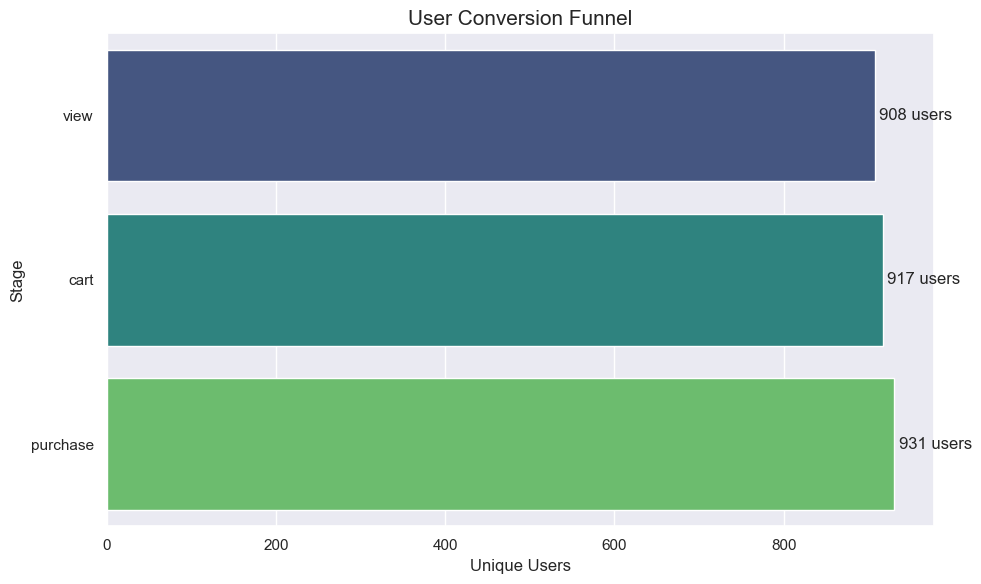

In [7]:
funnel_df = funnel.reset_index()
funnel_df.columns = ['Stage', 'Unique Users']

plt.figure(figsize=(10,6))

sns.barplot(
    data=funnel_df,
    x='Unique Users',
    y='Stage',
    hue='Stage',
    palette='viridis',
    legend=False
)

for index, value in enumerate(funnel_df['Unique Users']):
    plt.text(value + 5, index, f'{value} users', va='center')

plt.title('User Conversion Funnel', fontsize=15)
plt.xlabel('Unique Users')
plt.ylabel('Stage')

plt.tight_layout()
plt.show()

### Applying Feature Engineering 

In [8]:
cart_users = set(events[events['event_type'] == 'cart']['user_id'])
purchase_users = set(events[events['event_type'] == 'purchase']['user_id'])
abandones_users = cart_users - purchase_users

print(f"We Have {len(abandones_users)} users who abandones their carts.")
print("These are prime candidates for a 'Come back!' email campaign.")

We Have 63 users who abandones their carts.
These are prime candidates for a 'Come back!' email campaign.


#### Using RFM Analysis 

RFM stands for three specific metrics:
Recency (R): Days since the last purchase. (Lower is better/more active).
Frequency (F): Total number of purchases. (Higher is better/more loyal).
Monetary (M): Total money spent. (Higher is better/more profitable).

In [17]:
import datetime as dt

latest_date = orders['order_date'].max() + dt.timedelta(days=1)

rfm = orders.groupby('user_id').agg({
    'order_date': lambda x: (latest_date - x.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm_human = rfm.reset_index().merge(users[['user_id', 'name', 'city']], on='user_id')

print("Top 5 Spenders (Monetary Score = 5):")
print(rfm_human.sort_values('Monetary', ascending=False).head())

Top 5 Spenders (Monetary Score = 5):
    user_id  Recency  Frequency  Monetary R_Score F_Score M_Score  \
380    U441       52         10  20862.80       3       5       5   
168     U25       20         13  19570.90       4       5       5   
199    U279        6          9  18524.88       5       5       5   
595    U637       18         10  18392.94       4       5       5   
677    U710        6         12  18058.27       5       5       5   

              name              city  
380  Robert Barnes      South Ashley  
168    Jason Price  Lake Gailborough  
199   Tina Coleman        Strongfurt  
595   Susan Brooks          Adamfurt  
677  Patrick Mcgee      Darrellhaven  


In [43]:
def segment_customer(df):
    r = int(df['R_Score'])
    if r >= 4:
        return 'Active/Loyal'
    elif r <= 2:
        return 'At Risk/Churned'
    else:
        return 'Occasional'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

Segment
Active/Loyal       404
At Risk/Churned    398
Occasional         192
Name: count, dtype: int64


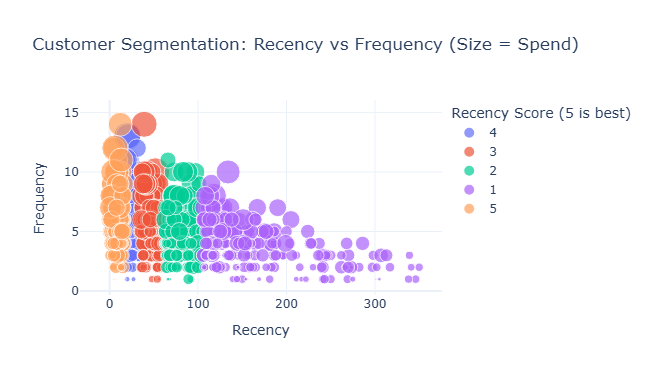

In [11]:
import plotly.express as px

fig = px.scatter(rfm_human, 
                 x="Recency", 
                 y="Frequency", 
                 size="Monetary", 
                 color="R_Score",
                 hover_name="name",
                 title="Customer Segmentation: Recency vs Frequency (Size = Spend)",
                 labels={"R_Score": "Recency Score (5 is best)"},
                 template="plotly_white")

fig.show()

### Product Analysis

In [12]:
items_with_details = order_items.merge(products[['product_id', 'product_name', 'category']], 
                                          on='product_id', 
                                          how='left')

product_perf = items_with_details.groupby('category').agg({
    'order_id': 'count',
    'item_price': 'sum'
}).rename(columns={'order_id': 'Sales_Volume', 'item_price': 'Total_Revenue'})

product_perf['Avg_Item_Price'] = product_perf['Total_Revenue'] / product_perf['Sales_Volume']

print("Corrected Product Performance:")
print(product_perf.sort_values(by='Total_Revenue', ascending=False))

Corrected Product Performance:
             Sales_Volume  Total_Revenue  Avg_Item_Price
category                                                
Home                 3534      891870.73      252.368628
Sports               3242      827599.47      255.274358
Clothing             1761      524602.25      297.900199
Beauty               1804      396017.63      219.521968
Electronics          2171      300844.97      138.574376


## Behavioural matrics / Master Master


In [13]:
master_df = order_items.merge(products, on='product_id', how='left').merge(orders, on='order_id', how='left').merge(users, on='user_id', how='left')
master_df['line_total'] = master_df['quantity'] * master_df['item_price']
print("Master Table created! Here are the columns we now have to work with:")
print(master_df.columns.tolist())

Master Table created! Here are the columns we now have to work with:
['order_item_id', 'order_id', 'product_id', 'quantity', 'item_price', 'product_name', 'category', 'price', 'rating', 'user_id', 'order_date', 'order_status', 'total_amount', 'name', 'email', 'gender', 'city', 'signup_date', 'line_total']


In [14]:
city_cat_spend = master_df.groupby(['city', 'category'])['line_total'].sum().reset_index()

electronics_top = city_cat_spend[city_cat_spend['category'] == 'Electronics'].sort_values('line_total', ascending=False)

print("Top 5 Cities for Electronics Spend:")
print(electronics_top.head(5))

Top 5 Cities for Electronics Spend:
                 city     category  line_total
2606      Port Amanda  Electronics     4160.23
3299      South Kevin  Electronics     3812.02
3621     Vasquezmouth  Electronics     3783.23
2700        Port John  Electronics     3650.69
3222  South Elizabeth  Electronics     3613.11


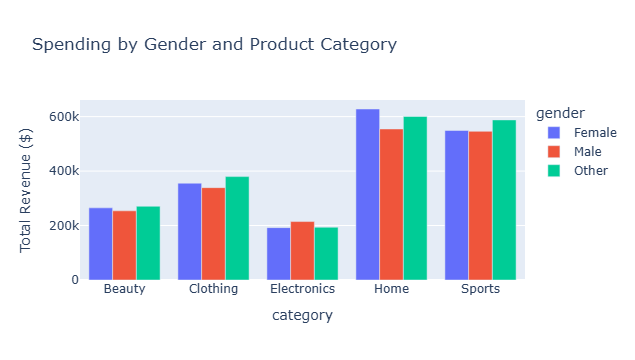

In [15]:
demo_growth = master_df.groupby(['gender', 'category'])['line_total'].sum().reset_index()

fig = px.bar(demo_growth, 
             x='category', 
             y='line_total', 
             color='gender', 
             barmode='group',
             title='Spending by Gender and Product Category',
             labels={'line_total': 'Total Revenue ($)'})

fig.show()

### Identifying at risk segment

We will use the rfm table we created earlier. We want to find users who:

Recency Score is 1 or 2 (Haven't bought in a long time).
Monetary Score is 4 or 5 (They used to spend a lot of money).

In [20]:
at_risk_vips = rfm[(rfm['R_Score'] <= 2) & (rfm['M_Score'] >= 4)].copy()
at_risk_list = at_risk_vips.reset_index().merge(users[['user_id', 'name', 'email', 'city']], on='user_id')
print(f"Alert: Found {len(at_risk_list)} High-Value customers at risk of churning!")
print(at_risk_list[['name', 'email', 'Recency', 'Monetary']].head())

Alert: Found 357 High-Value customers at risk of churning!
               name                        email  Recency  Monetary
0     Nicole Archer    williamherman@example.org       22  10137.74
1       Thomas Vang  elizabethjensen@example.com       20  14865.39
2     Kayla Hensley         rbeltran@example.org       50  10389.97
3  Jessica Martinez          bryan38@example.org       71   9631.36
4      Julie Garcia  thompsoncaitlin@example.com       20   6709.47


### Visualizing danger zone

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\3383570515.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



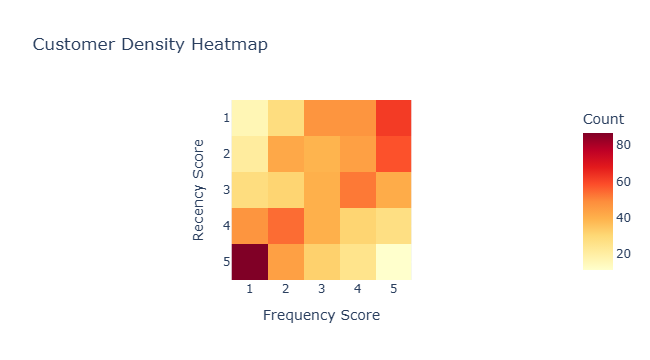

In [26]:
heatmap_data = rfm.groupby(['R_Score', 'F_Score']).size().unstack().fillna(0)
fig = px.imshow(heatmap_data,
               labels=dict(x="Frequency Score", y="Recency Score", color="Count"),
               x = ['1', '2', '3', '4', '5'],         
               y = ['1', '2', '3', '4', '5'],
               title = "Customer Density Heatmap",
               color_continuous_scale='YlOrRd')

fig.show()

## K-Means Clustering 

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 10)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

print("Customer Counts Per ML Cluster: ")
print(rfm['Cluster'].value_counts())

Customer Counts Per ML Cluster: 
Cluster
2    371
0    365
3    142
1    116
Name: count, dtype: int64


### Optimizing K-Means (The "Elbow Method")

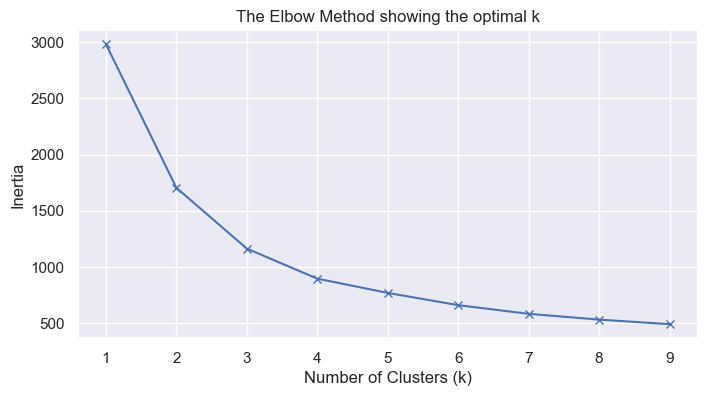

In [34]:
inertia = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeanModel.fit(scaled_features)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

## Time-Series Regression(Sales Forecasting)

In [28]:
from sklearn.linear_model import LinearRegression

daily_sales = master_df.groupby(master_df['order_date'].dt.date)['line_total'].sum().reset_index()
daily_sales.columns = ['date', 'sales']
daily_sales['day_index'] = range(len(daily_sales))

#### Training The Model

In [29]:
X = daily_sales[['day_index']]
y = daily_sales['sales']
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Predicting Next 30 Days

In [31]:
future_indices = pd.DataFrame(
    np.array(range(len(daily_sales), len(daily_sales) + 30)), 
    columns=['day_index']
)
forecast = model.predict(future_indices)

print(f"Average predicted daily revenue for next month: ${forecast.mean():.2f}")

Average predicted daily revenue for next month: $16639.04


## Model Evaluation: How good is our Forecast?

In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Model Mean Absolute Error: ${mae:.2f}")
print(f"R-Squared Score: {r2:.4f}") 

Model Mean Absolute Error: $4210.38
R-Squared Score: 0.0020


## NLP Sentiment Analysis

In [37]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

reviews['sentiment_score'] = reviews['review_text'].apply(get_sentiment)   

sentiment_vs_rating = reviews.groupby('rating')['sentiment_score'].mean()
print("Average Sentiment Score per Star Rating (1.0 = Very Positive, -1.0 = Very Negative):")
print(sentiment_vs_rating)

Average Sentiment Score per Star Rating (1.0 = Very Positive, -1.0 = Very Negative):
rating
1    0.050083
2    0.064306
3    0.060519
4    0.062270
5    0.051853
Name: sentiment_score, dtype: float64


## Advanced NLP: The Word Cloud


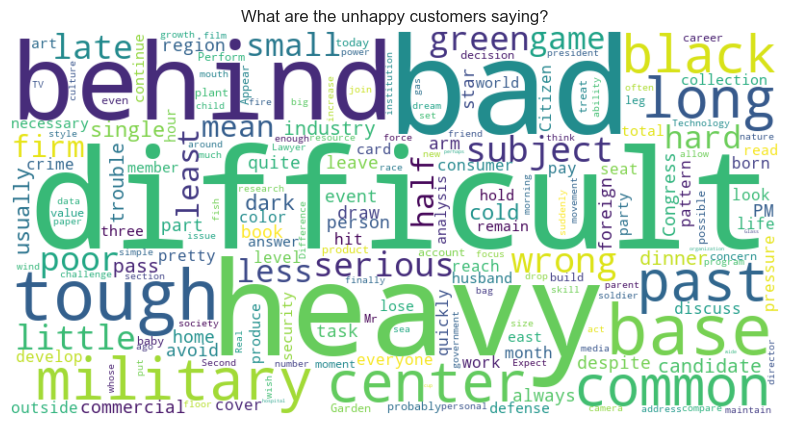

In [40]:
from wordcloud import WordCloud

negative_text = " ".join(reviews[reviews['sentiment_score'] < 0]['review_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("What are the unhappy customers saying?")
plt.show()

## Packaging ML pipelines

In [41]:
from sklearn.pipeline import Pipeline

clustering_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=4, random_state=42, n_init=10))
])

clustering_pipeline.fit(rfm[['Recency', 'Frequency', 'Monetary']])

new_customer = [[10, 5, 500.0]]
predicted_cluster = clustering_pipeline.predict(new_customer)
print(f"New customer belongs to Cluster: {predicted_cluster[0]}")

New customer belongs to Cluster: 0


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

